<a href="https://colab.research.google.com/github/HannaD2/A3_dlcv/blob/main/Copia_de_Lab1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Deep Learning para visión de computadoras
##Lab 1.2 Fundamentos matemáticos de CNN

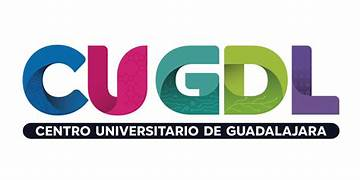

### Objetivo de la práctica

Implementar desde cero los bloques matemáticos:convolución discreta, pooling, campo receptivo, funciones de activación y batch normalization. Verificando con PyTorch para comprender que hacen los bloques internos.

#Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(1)
torch.manual_seed(1)
!pip install -q scikit-image
from skimage import data
import seaborn as sns
from matplotlib import patches
import time


plt.rcParams["figure.figsize"] = (6.0, 4.0)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

NumPy: 2.1.3
PyTorch: 2.11.0+cu128


# Parte A. Operaciones clasicas Numpy

##Convolución

**Ejemplo de convolución (paso a paso)**

<img src="https://raw.githubusercontent.com/adawolfs/Computer-Vision-Jalapa/master/images/conv_kernel.gif" width=500 height=500>

<img src="https://raw.githubusercontent.com/adawolfs/Computer-Vision-Jalapa/master/images/conv_kernel_1.gif" width=500 height=500>



1.   Imagen de 15x15
2.   Filtros
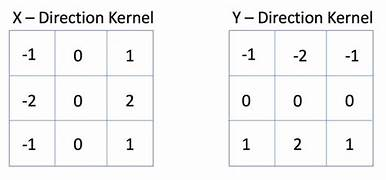

In [2]:
from scipy.signal import convolve2d
inp = np.random.choice(range(10), (15, 15))
filter_conv = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])
output = convolve2d(inp, filter_conv, mode='valid')

Implementación

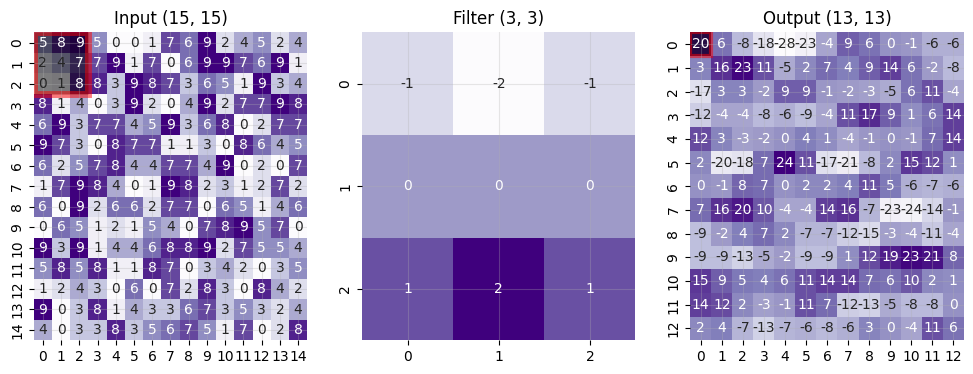

In [3]:
fig, ax = plt.subplots(ncols=3, figsize=(12, 4))

sns.heatmap(inp, annot=True, cbar=None, ax=ax[0], cmap='Purples')
sns.heatmap(filter_conv, annot=True, cbar=None, ax=ax[1], cmap='Purples')
sns.heatmap(output, annot=True, cbar=None, ax=ax[2], cmap='Purples')
g = ax[0]
rect = patches.Rectangle((0,0),3,3,linewidth=5,edgecolor='red',facecolor='black', alpha=0.5)


# Add the patch to the Axes
g.add_patch(rect)

rect_out = patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='red', facecolor='black', alpha=0.5)
ax[2].add_patch(rect_out)

ax[0].set_title(f"Input {inp.shape}")
ax[1].set_title(f"Filter {filter_conv.shape}")
ax[2].set_title(f"Output {output.shape}")
plt.show()

#**Padding**
Consiste en añadir ceros adicionales a los datos, matrices o señales de entrada, asegurando así que los datos tengan una forma o tamaño específicos adecuados para su posterior procesamiento.

In [4]:
def aplicar_padding(X, pad):
    """
    Argumentos:
    X   -- arreglo de NumPy con forma (m, n_H, n_W, n_C):
            m: num imágenes,
            n_H: alto
            n_W: ancho
            n_C: canales
    pad -- entero, cantidad de filas/columnas de ceros a añadir en cada borde.

    Regresa:
    X_pad -- arreglo con forma (m, n_H + 2*pad, n_W + 2*pad, n_C)
    """
    X_pad = np.pad(
        X,
        pad_width=((0, 0), (pad, pad), (pad, pad), (0, 0)),
        mode="constant",
        constant_values=0,
    )
    return X_pad


Implementación

x.shape     = (8, 6, 6, 3)
x_pad.shape = (8, 8, 8, 3)


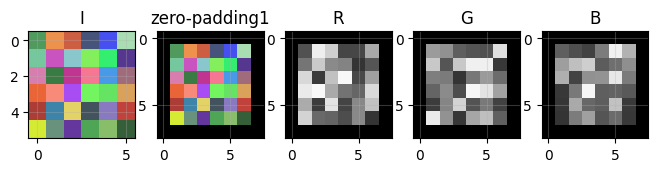

In [5]:
x = np.random.uniform(0.2, 1.0, size=(8, 6, 6, 3))
pad=1
x_pad = aplicar_padding(x,pad)
print("x.shape     =", x.shape)
print("x_pad.shape =", x_pad.shape)


fig, axs = plt.subplots(1, 5, figsize=(8, 4))
axs[0].imshow(x[0, :, :, :], cmap='gray', vmin=0, vmax=1)
axs[0].set_title("I")#original
axs[1].imshow(x_pad[0, :, :, :], cmap='gray', vmin=0, vmax=1)
axs[1].set_title("zero-padding"+ str(pad))
axs[2].imshow(x_pad[0, :, :, 0], cmap='gray', vmin=0, vmax=1)
axs[2].set_title("R")
axs[3].imshow(x_pad[0, :, :, 1], cmap='gray', vmin=0, vmax=1)
axs[3].set_title("G")
axs[4].imshow(x_pad[0, :, :, 2], cmap='gray', vmin=0, vmax=1)
axs[4].set_title("B")
#plt.tight_layout()
plt.show()





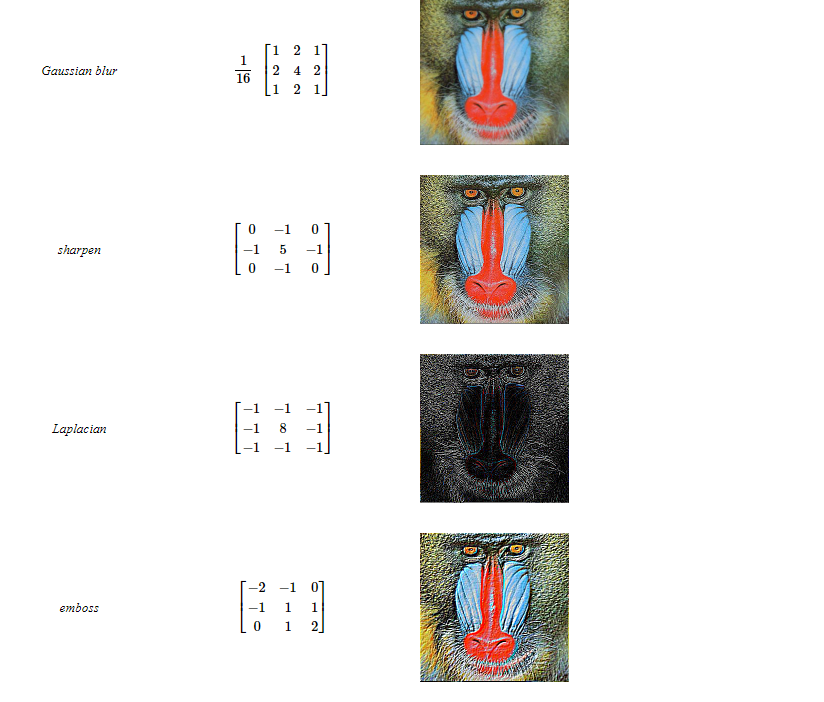






In [6]:
# Completa el cálculo de la dimensión de salida usando la fórmula:
# Dimension_salida = ((Dimension_entrada - Dimension_filtro + 2 * padding) / stride) + 1

N = x.shape[1]
F = filter_conv.shape[0]
P = pad
S = 1

Dimension_salida = ((N - F + 2 * P) // S) + 1

print(f"Fórmula: ((N - F + 2P) / S) + 1")
print(f"Dimensión de salida: {Dimension_salida}")

# raise NotImplementedError

Fórmula: ((N - F + 2P) / S) + 1
Dimensión de salida: 6


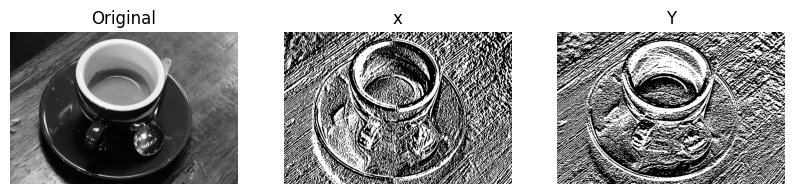

In [7]:
imagen_rgb = data.coffee()
output = convolve2d(imagen_rgb[:,:,1], filter_conv.T, mode='valid')
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(imagen_rgb[:,:,1], cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(convolve2d(imagen_rgb[:,:,1], filter_conv.T, mode='valid'), cmap='gray', vmin=0, vmax=1)
ax[1].set_title("x")
ax[1].axis("off")


ax[2].imshow(convolve2d(imagen_rgb[:,:,1], filter_conv, mode='valid'), cmap='gray', vmin=0, vmax=1)
ax[2].set_title("Y")
ax[2].axis("off")
plt.show()


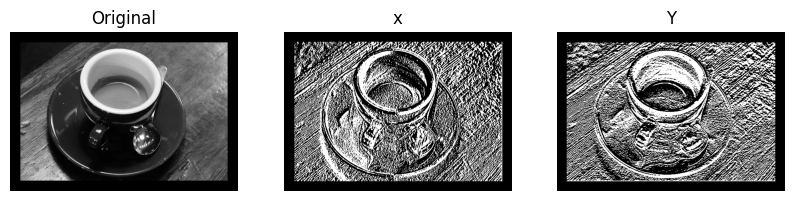

In [8]:
imagen_rgb = [data.coffee(), data.coffee()]
pad=30
imagen_rgb_pad = aplicar_padding(np.array(imagen_rgb),pad)
output = convolve2d(imagen_rgb_pad[0][:,:,1], filter_conv.T, mode='valid')
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(imagen_rgb_pad[1][:,:,1], cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(convolve2d(imagen_rgb_pad[0][:,:,1], filter_conv.T, mode='valid'), cmap='gray', vmin=0, vmax=1)
ax[1].set_title("x")
ax[1].axis("off")


ax[2].imshow(convolve2d(imagen_rgb_pad[0][:,:,1], filter_conv, mode='valid'), cmap='gray', vmin=0, vmax=1)
ax[2].set_title("Y")
ax[2].axis("off")
plt.show()

In [9]:
N = imagen_rgb[0].shape[0]
F = filter_conv.shape[0]
P = pad
S = 1

Dimension_salida = ((N - F + 2 * P) // S) + 1

print(f"Fórmula: ((N - F + 2P) / S) + 1")
print(f"Dimensión de salida: {Dimension_salida}")

Fórmula: ((N - F + 2P) / S) + 1
Dimensión de salida: 458


# Stride

Stride


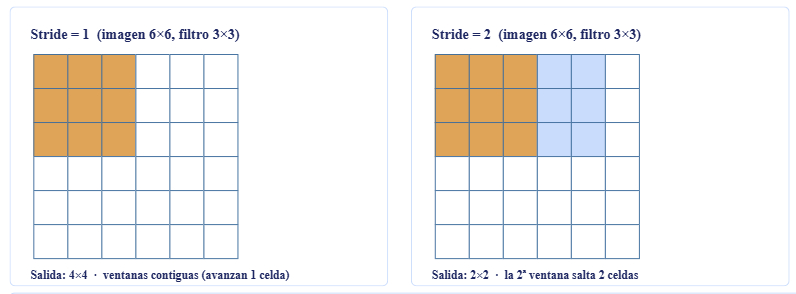

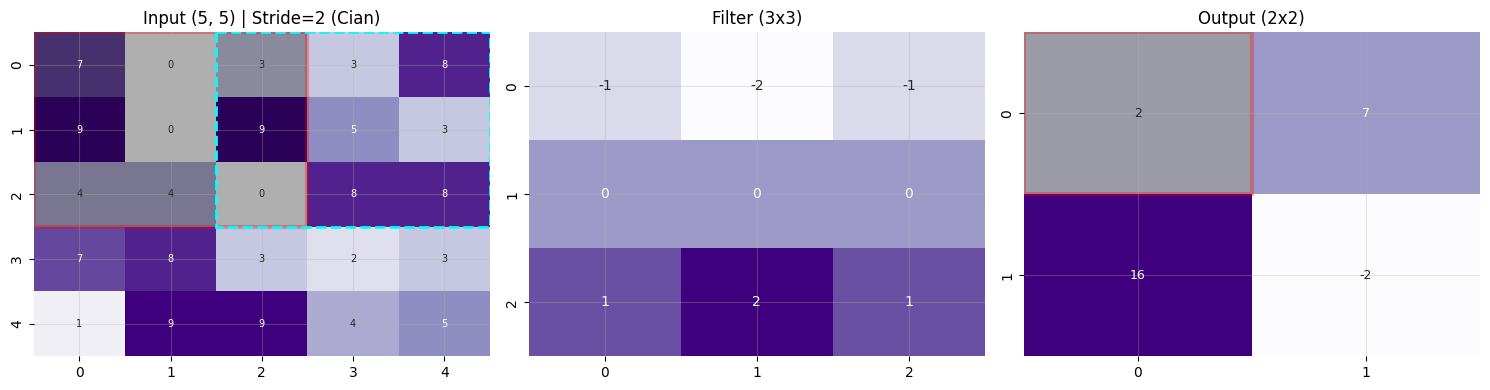

In [10]:
inp = np.random.choice(range(10), (5, 5))
filter_conv = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

stride = 2
pad = 0

H_in, W_in = inp.shape
f_h, f_w = filter_conv.shape

H_out = int((H_in - f_h + 2 * pad) // stride + 1)
W_out = int((W_in - f_w + 2 * pad) // stride + 1)

output = np.zeros((H_out, W_out), dtype=int)

for i in range(H_out):
    for j in range(W_out):
        r_start = i * stride
        r_end   = r_start + f_h
        c_start = j * stride
        c_end   = c_start + f_w

        ventana = inp[r_start:r_end, c_start:c_end]
        output[i, j] = np.sum(ventana * filter_conv)


fig, ax = plt.subplots(ncols=3, figsize=(15, 4))

sns.heatmap(inp, annot=True, annot_kws={"size": 7}, fmt="d", cbar=None, ax=ax[0], cmap='Purples')
sns.heatmap(filter_conv, annot=True, annot_kws={"size": 10}, fmt="d", cbar=None, ax=ax[1], cmap='Purples')
sns.heatmap(output, annot=True, annot_kws={"size": 9}, fmt="d", cbar=None, ax=ax[2], cmap='Purples')

rect_in_0 = patches.Rectangle((0, 0), f_w, f_h, linewidth=3, edgecolor='red', facecolor='black', alpha=0.3)
ax[0].add_patch(rect_in_0)

if W_out > 1:
    rect_in_1 = patches.Rectangle((stride, 0), f_w, f_h, linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--')
    ax[0].add_patch(rect_in_1)

rect_out = patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='red', facecolor='black', alpha=0.3)
ax[2].add_patch(rect_out)

ax[0].set_title(f"Input {inp.shape} | Stride={stride} (Cian)")
ax[1].set_title(f"Filter ({f_h}x{f_w})")
ax[2].set_title(f"Output ({H_out}x{W_out})")

plt.tight_layout()
plt.show()

In [11]:
# Completa el cálculo de la dimensión de salida usando la fórmula:
# Dimension_salida = ((Dimension_entrada - Dimension_filtro + 2 * padding) / stride) + 1

N = H_in
F = f_h
P = pad
S = stride

Dimension_salida = ((N - F + 2 * P) // S) + 1

print(f"Fórmula: ((N - F + 2P) / S) + 1")
print(f"Dimensión de salida: {Dimension_salida}")

# raise NotImplementedError

Fórmula: ((N - F + 2P) / S) + 1
Dimensión de salida: 2


#Pooling

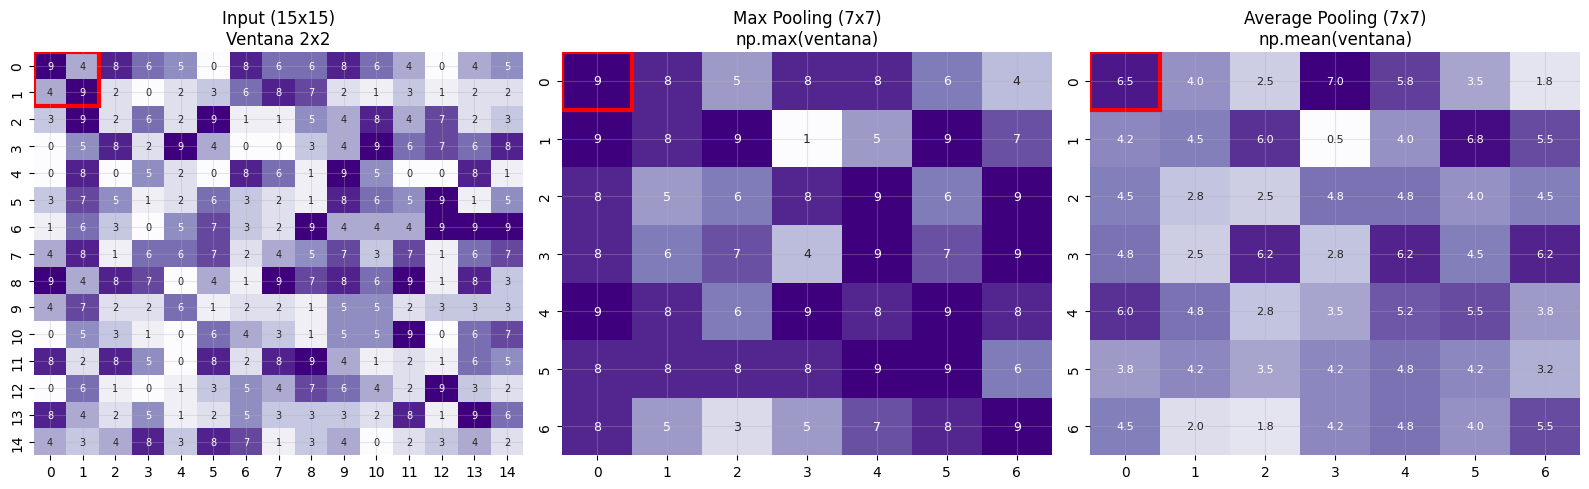

In [12]:
inp = np.random.choice(range(10), (15, 15))

pool_size = 2
stride = 2

H_in, W_in = inp.shape

H_out = int((H_in - pool_size) // stride + 1)
W_out = int((W_in - pool_size) // stride + 1)

out_max = np.zeros((H_out, W_out), dtype=int)
out_avg = np.zeros((H_out, W_out), dtype=float)

for i in range(H_out):
    for j in range(W_out):
        r_start = i * stride
        r_end   = r_start + pool_size
        c_start = j * stride
        c_end   = c_start + pool_size

        ventana = inp[r_start:r_end, c_start:c_end]

        out_max[i, j] = np.max(ventana)
        out_avg[i, j] = np.mean(ventana)


fig, ax = plt.subplots(ncols=3, figsize=(16, 5))

sns.heatmap(inp, annot=True, annot_kws={"size": 7}, fmt="d", cbar=False, ax=ax[0], cmap='Purples')
rect_in = patches.Rectangle((0, 0), pool_size, pool_size, linewidth=3, edgecolor='red', facecolor='none')
ax[0].add_patch(rect_in)
ax[0].set_title(f"Input (15x15)\nVentana {pool_size}x{pool_size}")

# Max Pooling
sns.heatmap(out_max, annot=True, annot_kws={"size": 9}, fmt="d", cbar=False, ax=ax[1], cmap='Purples')
rect_max = patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='red', facecolor='none')
ax[1].add_patch(rect_max)
ax[1].set_title(f"Max Pooling ({H_out}x{W_out})\nnp.max(ventana)")

# Average Pooling
sns.heatmap(out_avg, annot=True, annot_kws={"size": 8}, fmt=".1f", cbar=False, ax=ax[2], cmap='Purples')
rect_avg = patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='red', facecolor='none')
ax[2].add_patch(rect_avg)
ax[2].set_title(f"Average Pooling ({H_out}x{W_out})\nnp.mean(ventana)")

plt.tight_layout()
plt.show()

# Propagación hacia adelante de la capa convolucional

Ahora generalizamos: aplicamos varios **filtros** sobre toda la imagen, recorriendo alto y ancho con el stride indicado, sobre una entrada ya con padding.

Forma entrada: (1, 15, 15, 1)
Forma salida Z: (1, 12, 12, 1)


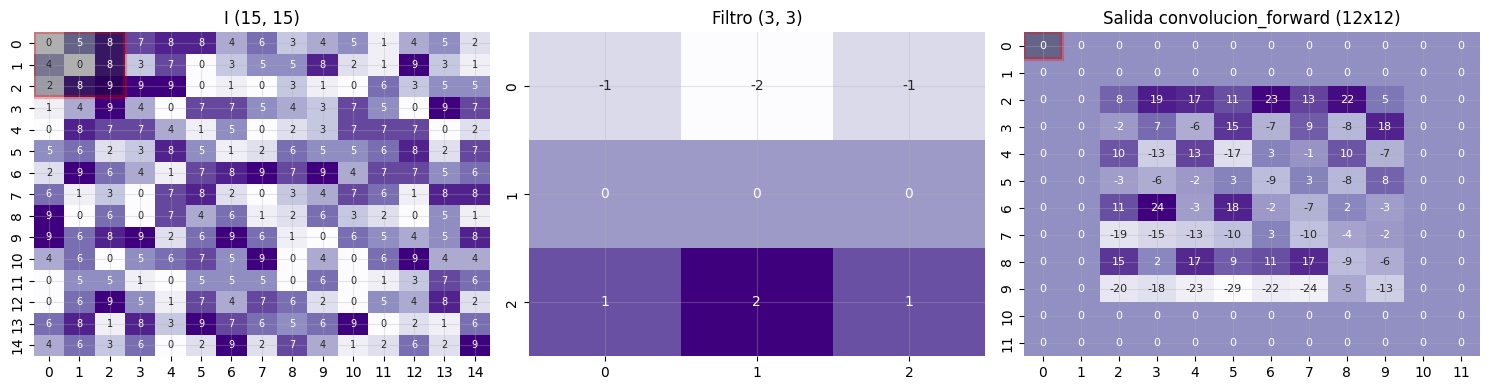

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patches
from scipy.signal import correlate2d

# 1. Padding en ejes espaciales (H y W: ejes 1 y 2)
def aplicar_padding(X, pad):
    if pad == 0:
        return X
    return np.pad(
        X,
        pad_width=((0, 0), (pad, pad), (pad, pad), (0, 0)),
        mode='constant',
        constant_values=0
    )

# 2. Paso elemental de convolución (producto punto elemento a elemento + sesgo)
def paso_convolucion(a_slice_prev, W, b):
    """
    a_slice_prev -- ventana de corte, forma (f, f, n_C_prev)
    W            -- filtro para un canal de salida, forma (f, f, n_C_prev)
    b            -- sesgo escalar o de forma (1, 1, 1)
    """
    s = np.multiply(a_slice_prev, W)
    Z = np.sum(s)
    Z = Z + b.item()
    return Z

# 3. Propagación hacia adelante
def convolucion_forward(A_prev, W, b, stride=1, pad=0):
    (m, n_H_prev, n_W_prev, n_C_prev) = A_prev.shape
    (f, f, _, n_C) = W.shape

    # División entera para admitir cualquier combinación de stride
    n_H = int((n_H_prev + 2 * pad - f) // stride) + 1
    n_W = int((n_W_prev + 2 * pad - f) // stride) + 1

    Z = np.zeros((m, n_H, n_W, n_C))
    A_prev_pad = aplicar_padding(A_prev, pad)

    for i in range(m):
        a_prev_pad = A_prev_pad[i]
        for h in range(n_H):
            y0, y1 = h * stride, h * stride + f
            for w in range(n_W):
                x0, x1 = w * stride, w * stride + f
                for c in range(n_C):
                    fragmento = a_prev_pad[y0:y1, x0:x1, :]
                    Z[i, h, w, c] = paso_convolucion(fragmento, W[:, :, :, c], b[:, :, :, c])
    return Z


inp_raw = np.random.choice(range(10), (15, 15))
A_prev = inp_raw.reshape(1, 15, 15, 1)


W = filter_conv.reshape(3, 3, 1, 1)

b = np.zeros((1, 1, 1, 1))

stride = 2
pad = 5

Z = convolucion_forward(A_prev, W, b, stride=stride, pad=pad)


scipy_out = correlate2d(inp_raw, filter_conv, mode='valid')
z_2d = Z[0, :, :, 0]

print("Forma entrada:", A_prev.shape)
print("Forma salida Z:", Z.shape)


fig, ax = plt.subplots(ncols=3, figsize=(15, 4))

sns.heatmap(inp_raw, annot=True, annot_kws={"size": 7}, fmt="d", cbar=False, ax=ax[0], cmap='Purples')
rect_in = patches.Rectangle((0, 0), 3, 3, linewidth=3, edgecolor='red', facecolor='black', alpha=0.3)
ax[0].add_patch(rect_in)
ax[0].set_title(f"I {inp.shape}")

sns.heatmap(filter_conv, annot=True, annot_kws={"size": 10}, fmt="d", cbar=False, ax=ax[1], cmap='Purples')
ax[1].set_title(f"Filtro {filter_conv.shape}")

sns.heatmap(z_2d, annot=True, annot_kws={"size": 8}, fmt=".0f", cbar=False, ax=ax[2], cmap='Purples')
rect_out = patches.Rectangle((0, 0), 1, 1, linewidth=3, edgecolor='red', facecolor='black', alpha=0.3)
ax[2].add_patch(rect_out)
ax[2].set_title(f"Salida convolucion_forward ({z_2d.shape[0]}x{z_2d.shape[1]})")

plt.tight_layout()
plt.show()

**Ejercicio propuesto — filtro detector de bordes**

Aplica tu función `convolucion_forward` sobre una imagen sintética (una cruz blanca en un fondo negro) usando el filtro de detección de bordes visto en la presentación:

$$
\begin{bmatrix} -1 & -1 & -1 \\ -1 & 8 & -1 \\ -1 & -1 & -1 \end{bmatrix}
$$

`stride=1` y `pad=0`.

# Parte B. Comparación con `torch.nn.Conv2d`

Vamos a cargar **exactamente los mismos pesos** en una capa `nn.Conv2d` de PyTorch y comprobar que produce el mismo resultado que en NumPy.

PyTorch espera los tensores en formato `NCHW` (lote, canales, alto, ancho), mientras que arriba trabajamos en `NHWC`. Hay que transponer con cuidado.



##PyTorch: Tensores
NumPy es un excelente framework, pero no puede utilizar GPU para acelerar sus cálculos numéricos. Para las redes neuronales profundas modernas, las GPU suelen proporcionar aceleraciones de 50 veces o más , por lo que, lamentablemente, NumPy no será suficiente para el aprendizaje profundo actual.

Un **tensor de PyTorch** es conceptualmente idéntico a un array de NumPy: un tensor es un array n-dimensional, y PyTorch proporciona muchas funciones para operar con estos tensores.
Internamente, los tensores pueden gestionar un grafo computacional y gradientes, pero también son útiles como herramienta genérica para la computación científica.

##PyTorch: nn
1.   import torch.nn as nn

Define un conjunto de módulos (nn) , que son aproximadamente equivalentes a las capas de una red neuronal. Un módulo recibe tensores de entrada y calcula tensores de salida, pero también puede contener un estado interno, como tensores con parámetros entrenables. El nnpaquete también define un conjunto de funciones de pérdida útiles que se utilizan habitualmente en el entrenamiento de redes neuronales.




2.   Definición de hiperparámetros dimensionales

batch_size: Define la cantidad de imágenes procesadas en un único lote hacia adelante.
H, W : Define las dimensiones espaciales de entrada: {} píxeles de alto y {} de ancho.
c_in, c_out: Define los canales: {} de entrada (ej. RGB) y {} mapas de características de salida.
f: Tamaño del kernel (f x f)
pad, stride: Relleno de ceros en los bordes (pad=1) y desplazamiento del filtro (stride=1).




In [14]:
batch_size = 32
H, W = 64, 64
c_in, c_out = 3, 16
f = 3
pad, stride = 1, 1
# Imprime las dimensiones del tensor de entrada (formato NHWC de NumPy)
print(f"Dimensiones de entrada : ({batch_size}, {H}, {W}, {c_in})")
# raise NotImplementedError
# Imprime las propiedades del banco de filtros y sus hiperparámetros de convolución.
print(f"Filtro                 : ({f}, {f}, {c_in}, {c_out})")
print(f"Padding                : {pad}")
print(f"Stride                 : {stride}")
# raise NotImplementedError

Dimensiones de entrada : (32, 64, 64, 3)
Filtro                 : (3, 3, 3, 16)
Padding                : 1
Stride                 : 1


In [15]:
Dimension_salida = ((N - F + 2 * P) // S) + 1

##Responde

1.   ¿Por qué con pad=1, stride=1 y f=3 la salida conserva exactamente el tamaño 64x64?
    (O = floor((N + 2*pad - f) / stride) + 1).  

Con pad = 1 se agrega un pixel de relleno en cada borde de la imagen, lo que aumenta temporalmente la dimension, el filtro es 3x3  y el stride es 1 y el resultado es 64, por lo que conserva la dimensión

2. Según la documentación de nn.Conv2d, ¿qué parámetro permitiría procesar cada canal de
    entrada de forma independiente sin combinarlos todos? (argumento 'groups').  

El parametro "groups" permite dividir la entrada en grupos para procesarlos de forma independiente y cada grupo puede ser procesado sin combinarse con los demás
3. ¿Qué implicación tiene fijar 'dilation > 1'? ¿Cómo altera el campo receptivo sin añadir pesos?  
Al fijarlo, se introducen espacios entre los elementos del kernel, permitiendo que el filtro observe una región más grande de la entrada, sin aumentar el tamaño del kernel ni añadir nuevos pesos


In [16]:
A_np = np.random.randn(batch_size, H, W, c_in).astype(np.float32)

# Inicializa pesos aleatorios escalados por 0.1 para evitar explosión numérica en la suma.
W_np = (np.random.randn(f, f, c_in, c_out) * 0.1).astype(np.float32)

# Crea un vector de sesgo (bias) inicializado en cero para cada uno de los 16 canales de salida.
b_np = np.zeros((1, 1, 1, c_out), dtype=np.float32)

# Instancia la capa convolucional 2D oficial de PyTorch en CPU.
conv_torch_cpu = nn.Conv2d(c_in, c_out, kernel_size=f, stride=stride, padding=pad, bias=True)

# Desactiva el cálculo de gradientes para ahorrar memoria y permitir la mutación manual de tensores.
with torch.no_grad():
    # Transpone W_np de (H_f, W_f, C_in, C_out) a (C_out, C_in, H_f, W_f) y copia los valores en la capa.
    conv_torch_cpu.weight.copy_(torch.tensor(W_np.transpose(3, 2, 0, 1)))
    # Aplana b_np a vector unidimensional de tamaño [16] y lo asigna al sesgo de PyTorch.
    conv_torch_cpu.bias.copy_(torch.tensor(b_np.reshape(-1)))

# Convierte la entrada NumPy de formato NHWC a NCHW transponiendo los ejes (0, 3, 1, 2) para PyTorch.
A_torch_cpu = torch.tensor(A_np.transpose(0, 3, 1, 2))

##Responde

Lectura : https://docs.pytorch.org/docs/main/generated/torch.nn.modules.conv.Conv2d.html

1. Define la función matematica de class Conv2d(_ConvNd)

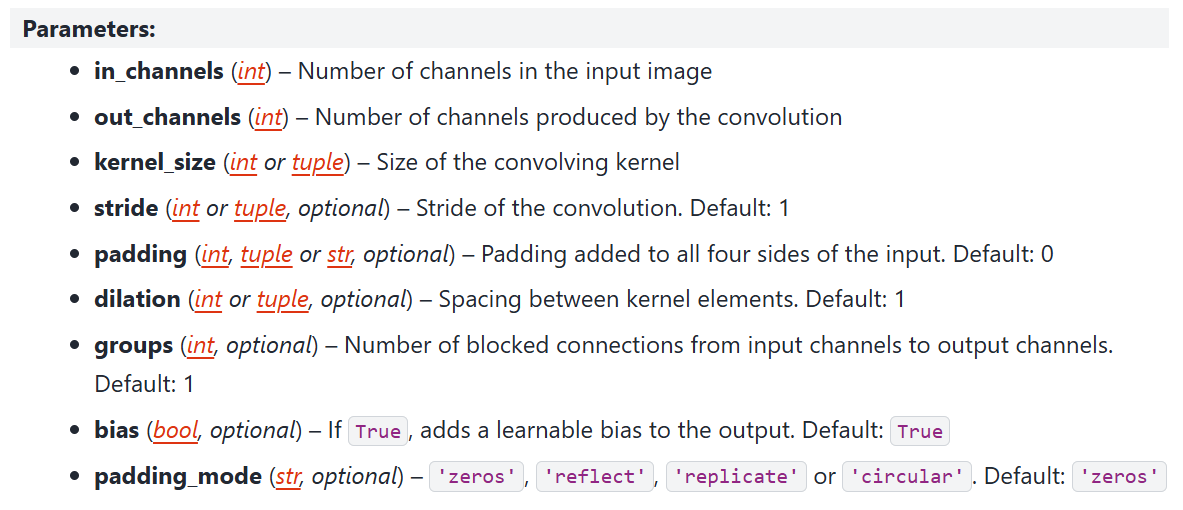


2. Define weight  
Representa los pesos aprendibles de la capa convolucional, estos pesos forman los filtros o kernels que se desplazan sobre la entrada para detectar diferentes características, como bordes, características, texturas o patrones
3. Define bias  
parametro aprendible que suma el resultado de la convolucion antes de aplicar la función de activación, cada canal de salida puede tener su propio valor de bias  
Su función es proporcionar un desplazamiento adicional que permite al modelo ajustar mejor sus resultados
4. Si el modelo se entrena con BatchNorm o convolución continua sin capas previas,
    ¿por qué 'bias=False' es una mejor práctica recomendada para ahorrar memoria y cómputo?  
Cuando una capa convolucional es seguida por Batch Normalization, el parámetro bias de la convolución puede ser redundante, ya que BatchNorm incluye sus propios parámetros aprendibles para desplazar y escalar la salida
5. Define dilation y ejemplifica la siguiente imagen  
Dilation es un parámetro que controla la separacion entre los valores de un kernel durante la convolución, al aumentar la dilatación, el filtro puede abarcar una zona más grande de la imagen de entrada sin aumentar el tamaño del kernel ni la cantidad de pesos  
En la imagen se puede observar que con dilation=1 los puntos del filtro están juntos, con dilation=2 se dejan espacios entre ellos y con dilation=3 los espacios son todavía mayores, esto hace que el filtro pueda observar una parte más grande de la imagen utilizando la misma cantidad de pesos

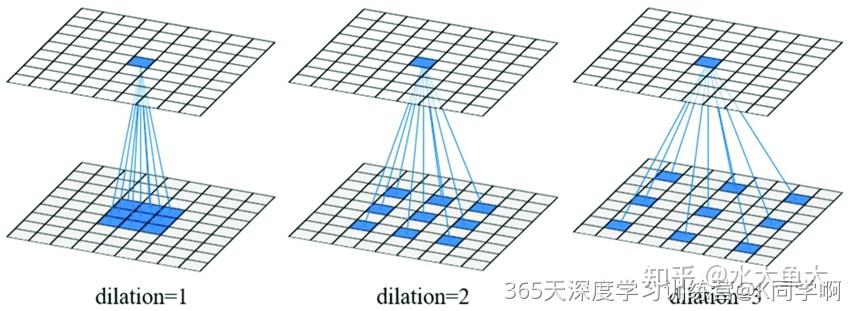

Investiga los diferentes padding_mode (str, optional) – 'zeros', 'reflect', 'replicate' or 'circular'.
Agrega una imagen de ejemplo para cada uno y una descripción

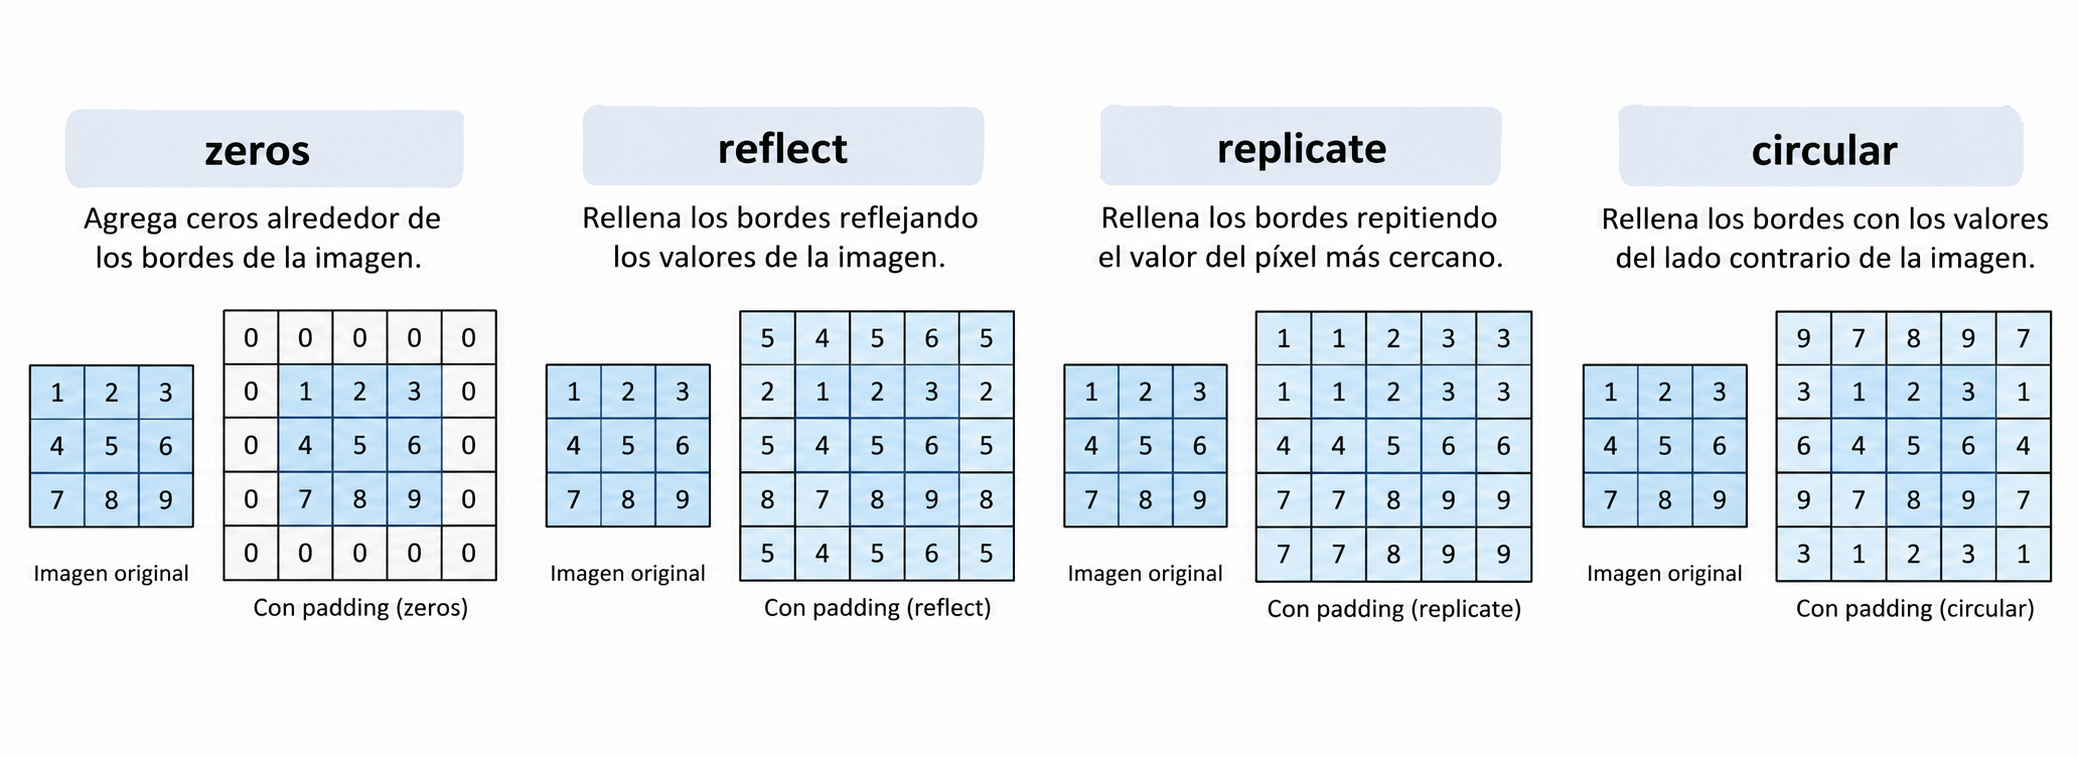

Imagen creada por la escases de imagenes y la cantidad de código en cada imagen (se me trabó todo)



3. Consulta la sección de 'Memory Format' del PyTorch Tuning Guide:
    ¿Qué es 'torch.channels_last' y por qué acelera drásticamente nn.Conv2d en arquitecturas modernas?  
torch.channels_last es un formato de memoria que organiza los canales de una imagen de una manera diferente, lo que permite que las convoluciones se ejecuten de forma más eficiente en hardware moderno, especialmente al utilizar GPU y Tensor Cores, por lo que puede acelerar nn.Conv2d
    
 3. ¿Por qué usamos copy_() con guion bajo al final en lugar de asignar con '=' directo?  
 Porque copia los valores dentro del tensor orininal, el guion bajo nos indica que modifica ese tensor, mientras que "=" asigna una nueva referencia y no copia lo que hay en el tensor ya existente


##BENCHMARK 1 - Implementación NumPy

## Responde
1. En esta corrida, ¿cuántas iteraciones totales realizan los bucles combinados?

En esta corrida, los bucles combinados realizan 2,097,152 iteraciones  
Esto se obtiene multiplicando las 32 imágenes del batch por las 64 posiciones de alto, las 64 posiciones de ancho y los 16 canales de salida

In [17]:
t0 = time.perf_counter()

_ = convolucion_forward(A_np, W_np, b_np, stride=stride, pad=pad)

tiempo_numpy = time.perf_counter() - t0

##BENCHMARK 2 - Pythorch en CPU (VECTORIZADO / GEMM)

In [18]:
# Bloque sin seguimiento de gradientes para benchmark de inferencia pura.
with torch.no_grad():
    # Ejecución previa ("warm-up") para cargar librerías dinámicas y preparar cachés de CPU.
    _ = conv_torch_cpu(A_torch_cpu)

t0 = time.perf_counter()

with torch.no_grad():
    for _ in range(5):
        _ = conv_torch_cpu(A_torch_cpu)

tiempo_torch_cpu = (time.perf_counter() - t0) / 5

##BENCHMARK 3 - PYTORCH EN GPU (CUDA / cuDNN)

In [19]:
cuda_disponible = torch.cuda.is_available()

# Inicializa la variable de tiempo GPU en None en caso de no haber acelerador disponible.
tiempo_torch_gpu = None

# Condicional que solo se activa si hay hardware GPU utilizable.
if cuda_disponible:

    # Transfiere los pesos de la capa convolucional de la RAM del host a la VRAM de la GPU.
    conv_torch_gpu = conv_torch_cpu.cuda()

    # Transfiere el tensor de entrada de la memoria principal a la memoria gráfica (VRAM).
    A_torch_gpu = A_torch_cpu.cuda()

    # Bloque sin registro de gradientes.
    with torch.no_grad():
        # Corrida de calentamiento (warm-up) para compilar kernels de CUDA y reservar buffers.
        _ = conv_torch_gpu(A_torch_gpu)

    # Bloquea la CPU hasta que la GPU finalice todas las tareas pendientes de la cola CUDA.
    torch.cuda.synchronize()

    # Toma marca de tiempo de CPU previa al ciclo de pruebas.
    t0 = time.perf_counter()

    # Bloque sin registro de gradientes.
    with torch.no_grad():
        # Ejecuta 10 iteraciones sobre la GPU para calcular una media estadística sólida.
        for _ in range(10):
            # Encola la operación convolucional en el flujo (stream) de CUDA.
            _ = conv_torch_gpu(A_torch_gpu)

    torch.cuda.synchronize()

    # Calcula el tiempo promedio real de ejecución en la GPU dividiendo entre 10 pasadas.
    tiempo_torch_gpu = (time.perf_counter() - t0) / 10

##Comparación


NumPy (Bucles for) : 23.1018 s
PyTorch CPU          : 0.0033 s  (Speedup: 7019.5x)
PyTorch GPU (CUDA)   : 0.000362 s (Speedup: 63842.5x)


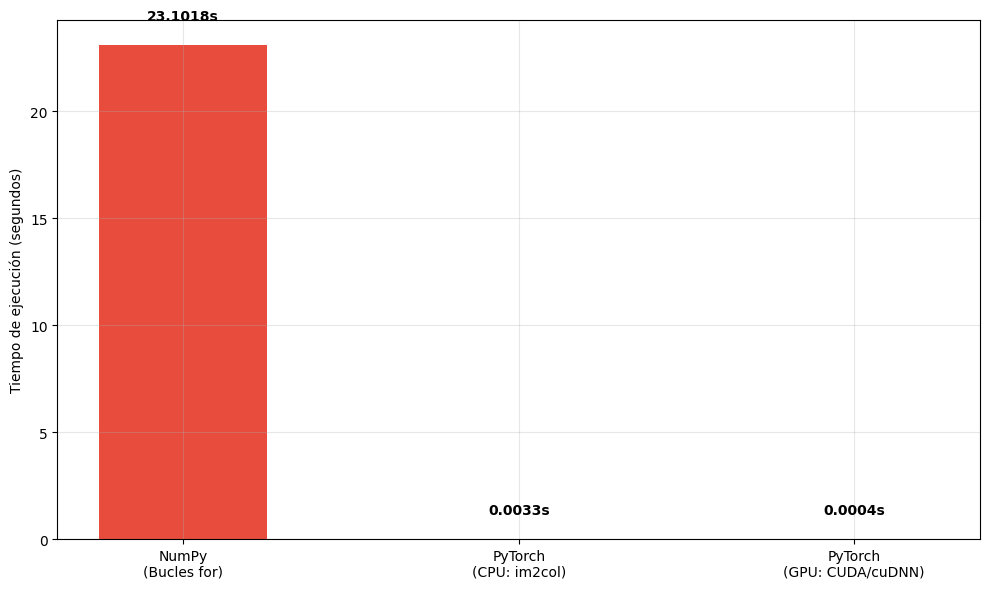

In [20]:
print("\n" + "="*50)

# Muestra el tiempo obtenido por la versión pura en NumPy
print(f"NumPy (Bucles for) : {tiempo_numpy:.4f} s")

# Muestra el tiempo en CPU y calcula el factor de aceleración respecto a NumPy.
print(f"PyTorch CPU          : {tiempo_torch_cpu:.4f} s  (Speedup: {tiempo_numpy / tiempo_torch_cpu:.1f}x)")

# Si se corrió en GPU, muestra su tiempo y la aceleración absoluta comparada con los ciclos for.
if cuda_disponible:
    print(f"PyTorch GPU (CUDA)   : {tiempo_torch_gpu:.6f} s (Speedup: {tiempo_numpy / tiempo_torch_gpu:.1f}x)")

# Cierra el bloque separador de resultados en consola.
print("="*50)


# Lista con los nombres explicativos de cada metodología probada.
etiquetas = ['NumPy\n(Bucles for)', 'PyTorch\n(CPU: im2col)']

# Lista con los tiempos respectivos medidos en segundos.
tiempos = [tiempo_numpy, tiempo_torch_cpu]

# Lista con los códigos hexadecimales de color para cada barra (rojo y azul).
colores = ['#E74C3C', '#3498DB']

# Agrega la barra correspondiente a GPU si CUDA estuvo disponible durante la prueba.
if cuda_disponible:
    etiquetas.append('PyTorch\n(GPU: CUDA/cuDNN)')  # Nombre del método acelerado.
    tiempos.append(tiempo_torch_gpu)                  # Tiempo registrado en GPU.
    colores.append('#2ECC71')                        # Color verde para destacar la GPU.

# Crea la figura y un eje principal de tamaño 10x6 pulgadas.
fig, ax1 = plt.subplots(figsize=(10, 6))

# Dibuja las barras verticales con ancho asignado y sus respectivos colores.
barras = ax1.bar(etiquetas, tiempos, color=colores, width=0.5)

# Etiqueta el eje vertical indicando la magnitud física de medición.
ax1.set_ylabel("Tiempo de ejecución (segundos)")

# Itera sobre cada barra rectangular y su tiempo para imprimir el valor numérico arriba del bloque.
for barra, t in zip(barras, tiempos):
    # Imprime texto centrado horizontalmente con holgura vertical proporcional al valor máximo.
    ax1.text(barra.get_x() + barra.get_width()/2, t + 0.05 * max(tiempos),
             f"{t:.4f}s", ha='center', fontweight='bold')

# Ajusta márgenes automáticamente para que las etiquetas no se corten.
plt.tight_layout()

# Renderiza la figura en pantalla o en la libreta interactiva.
plt.show()

#Pooling manual vs nn.MaxPool2d / nn.AvgPool2d

Implementamos ahora el submuestreo por bloques en sus dos variantes vistas en clase: Max Pooling y Average Pooling. A diferencia de la convolución, las capas de pooling no aprenden pesos ($W$) ni sesgos ($b$), sino que aplican una función fija de agregación sobre ventanas locales de cada canal de forma independiente.

Completa la función pooling_forward_numpy para soportar tanto 'max' como 'average', aplicando la reducción adecuada sobre cada ventana fragmento.

Equivalencia de dimensiones: Asegúrate de calcular las dimensiones de salida espacial ($n_H, n_W$) considerando división entera (//).

Comparación con PyTorch: Instancia nn.MaxPool2d y nn.AvgPool2d con los hiperparámetros dados y verifica que la diferencia absoluta máxima frente a tu versión manual sea menor a $10^{-5}$.

## Responde
¿Qué ocurre si defines stride < f (ventanas solapadas o overlapping pooling) en lugar de la configuración usual stride == f?

So stride < f las ventanas de pooling se superponen, por lo que algunos valores de la entrada pueden ser utilizados en otra ventana, en stride == f las ventanas no se superponen, lo que hace que se conserve más información y la salida puede tener un tamaño mayor

In [22]:
# raise NotImplementedError
